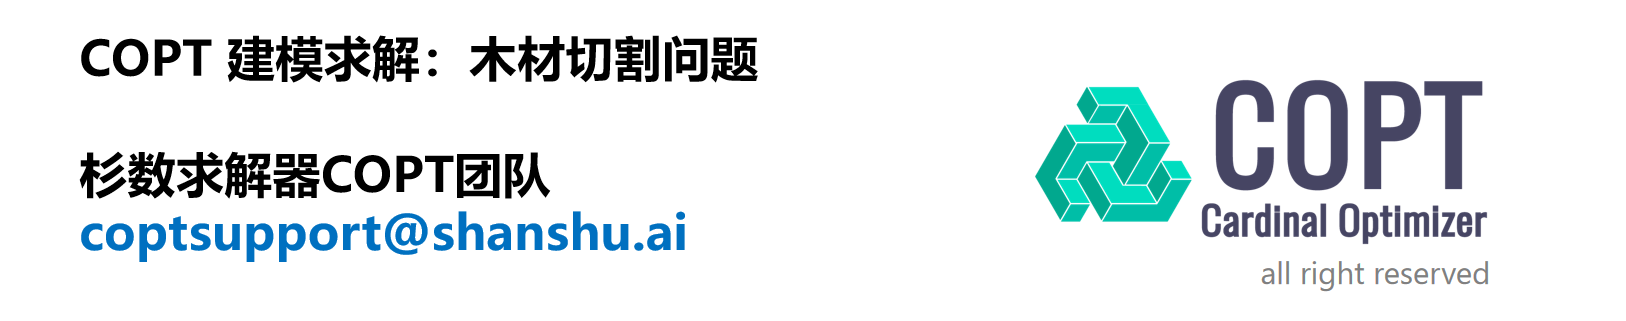

> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib


In [ ]:
# 中文字体：运行环境通常没有 CJK 字体，注册随仓库分发的思源黑体子集
import os, urllib.request, matplotlib, matplotlib.font_manager as fm
FONT = 'NotoSansCJKsc-Regular-subset.otf'
CAND = [FONT, os.path.join('..', 'assets', FONT), os.path.join('..', '..', 'assets', FONT),
        os.path.join('assets', FONT)]
URLS = [
    'https://gitee.com/tztgracious/copt-colab-cases/raw/main/assets/' + FONT,
    'https://raw.githubusercontent.com/tztgracious/copt-colab-cases/main/assets/' + FONT,
]
path = next((p for p in CAND if os.path.exists(p)), None)
if path is None:
    for u in URLS:
        try:
            urllib.request.urlretrieve(u, FONT); path = FONT; break
        except Exception:
            continue
if path:
    fm.fontManager.addfont(path)
    matplotlib.rcParams['font.sans-serif'] = [fm.FontProperties(fname=path).get_name()]
    matplotlib.rcParams['axes.unicode_minus'] = False
    print('中文字体已就绪:', matplotlib.rcParams['font.sans-serif'][0])
else:
    print('未能加载中文字体，图表中的中文可能显示为方块')

# 木材切割问题代码实现
## 使用COPT建模求解木材切割问题的步骤

1. **导入COPT-Python接口库** `coptpy`，以及用于绘图的 `matplotlib`

2. **添加模型数据**
    - 原木长度、各规格木板的长度与需求量
    - 递归枚举全部可行的切割方案，并用图形展示

3. **创建COPT求解环境与模型**

4. **构建模型：依次添加三要素**
    - **决策变量**：
        - $x_j$：非负整数变量，按第 $j$ 种方案切割的原木数量（根）
    - **目标函数**：消耗的原木总数最少
    - **约束条件**：
        - 每种规格切出的总数不少于订单需求

5. **求解**

6. **查看、分析结果**：输出并绘制最优切割方案，对比需求与产出

7. **案例拓展**：利用列生成技术加快模型求解
    - 建立限制主问题与定价子问题
    - 迭代生成新方案，并观察目标值与影子价格的变化
    - 恢复整数性得到最终方案，并在更大的算例上对比两种方法

本案例的数学模型与符号含义见案例描述，下面按上述步骤逐段实现。

## 导入COPT-Python接口库
除 `coptpy` 之外，还导入 `matplotlib` 用于绘图。为了让图中的中文正常显示，这里按常见系统字体依次尝试，找到可用的即采用。

In [1]:
import math
import coptpy as cp
from coptpy import COPT

import matplotlib.pyplot as plt
from matplotlib import font_manager

# 中文字体，按系统常见字体依次尝试
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
for font_name in ['Noto Sans CJK SC', 'Microsoft YaHei', 'SimHei', 'PingFang SC', 'Noto Sans CJK SC', 'Noto Sans CJK JP']:
    if font_name in installed_fonts:
        plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', font_name]
        break
plt.rcParams['axes.unicode_minus'] = False

# 图表配色：每种木板规格一种颜色，余料用灰色
COLORS = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300']
WASTE_COLOR = '#d9d8d4'

## 添加模型数据
原木长度为 20 米。四种木板的长度分别为 3、7、9、16 米，需求量依次为 25、30、14、8 块。列表 `types` 和 `demand` 的第 $i$ 个元素分别对应数学模型中的 $l_i$ 和 $d_i$。

In [2]:
length = 20                # 原木长度 L（米）
types  = [3, 7, 9, 16]     # 各规格木板长度 l_i（米）
demand = [25, 30, 14, 8]   # 各规格需求量 d_i（块）
num_types = len(types)

### 枚举可行的切割方案
模型中的每个变量对应一种切割方案，因此建模前需要先得到全部可行方案。一个方案用列表 `[a1, a2, a3, a4]` 表示，四个数分别是 3 米、7 米、9 米、16 米木板的切割块数，只要 $3a_1 + 7a_2 + 9a_3 + 16a_4 \leq 20$ 就是可行的。

下面的函数用递归的方式逐个规格确定切割块数：先确定 3 米木板切几块，再在剩余长度内确定 7 米木板切几块，依此类推，处理完最后一种规格就得到一个完整方案。全零方案（什么都不切）没有意义，枚举时跳过。

枚举结果中有一部分方案没有把原木用满，例如只切一块 3 米木板、剩下 17 米作为余料。这类方案在最优解中不会被采用，因为把余料也切成木板不会违反任何约束。这里保留它们是为了与数学模型中的集合 $J$ 保持一致，对求解结果没有影响。

In [3]:
def enumerate_patterns(length, types):
    """枚举全部非零的可行切割方案，每个方案是各规格切割块数组成的列表"""
    patterns = []

    def recurse(idx, remaining, current):
        if idx == len(types):
            if any(current):
                patterns.append(current.copy())
            return
        for k in range(remaining // types[idx], -1, -1):
            current[idx] = k
            recurse(idx + 1, remaining - k * types[idx], current)
        current[idx] = 0

    recurse(0, length, [0] * len(types))
    return patterns


plans = enumerate_patterns(length, types)
num_plans = len(plans)

print(f'原木长度 {length} 米，木板规格 {types} 米，共有 {num_plans} 种可行切割方案：\n')
print('方案编号  ' + '  '.join(f'{t:>3}米' for t in types) + '   余料')
for j, plan in enumerate(plans):
    waste = length - sum(a * l for a, l in zip(plan, types))
    print(f'{j:>6}    ' + '  '.join(f'{a:>4}' for a in plan) + f'   {waste:>3}')

原木长度 20 米，木板规格 [3, 7, 9, 16] 米，共有 23 种可行切割方案：

方案编号    3米    7米    9米   16米   余料
     0       6     0     0     0     2
     1       5     0     0     0     5
     2       4     1     0     0     1
     3       4     0     0     0     8
     4       3     1     0     0     4
     5       3     0     1     0     2
     6       3     0     0     0    11
     7       2     2     0     0     0
     8       2     1     0     0     7
     9       2     0     1     0     5
    10       2     0     0     0    14
    11       1     2     0     0     3
    12       1     1     1     0     1
    13       1     1     0     0    10
    14       1     0     1     0     8
    15       1     0     0     1     1
    16       1     0     0     0    17
    17       0     2     0     0     6
    18       0     1     1     0     4
    19       0     1     0     0    13
    20       0     0     2     0     2
    21       0     0     1     0    11
    22       0     0     0     1     4


表格中每一行就是一个方案，最后一列是该方案每根原木的余料。用图形来看会更直观：下面把每个方案画成一根横放的原木，彩色段表示切出的木板，灰色段表示余料。这个绘图函数在后面展示求解结果时还会用到。

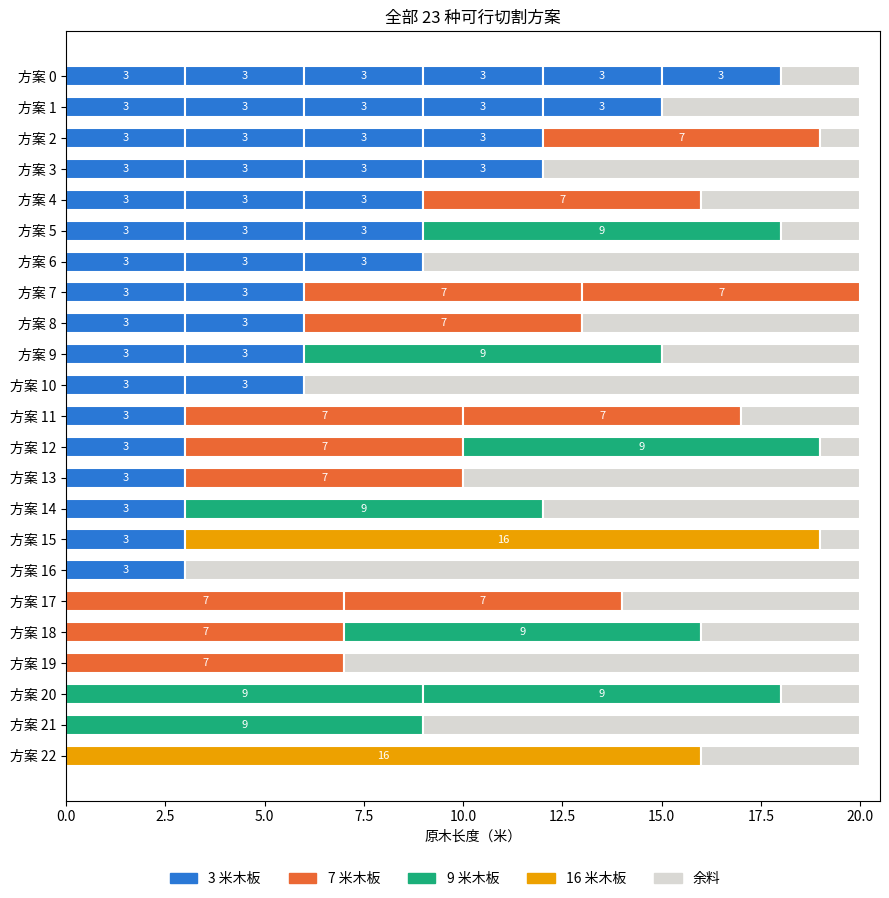

In [4]:
def plot_patterns(ax, patterns, types, length, counts=None, row_labels=None):
    """把每个切割方案画成一根横放的原木：彩色段为木板，灰色段为余料；counts 给出时标注使用根数"""
    for row, plan in enumerate(patterns):
        pos = 0
        for i, (a, l) in enumerate(zip(plan, types)):
            for _ in range(a):
                ax.barh(row, l, left=pos, color=COLORS[i], edgecolor='white', linewidth=1.5, height=0.65)
                ax.text(pos + l / 2, row, f'{l}', ha='center', va='center', fontsize=8, color='white')
                pos += l
        if pos < length:
            ax.barh(row, length - pos, left=pos, color=WASTE_COLOR, edgecolor='white', linewidth=1.5, height=0.65)
        if counts is not None:
            ax.text(length + 0.4, row, f'× {counts[row]} 根', va='center', fontsize=10)
    ax.set_yticks(range(len(patterns)))
    ax.set_yticklabels(row_labels or [f'方案 {k}' for k in range(len(patterns))])
    ax.invert_yaxis()
    ax.set_xlim(0, length + (4 if counts is not None else 0.5))
    ax.set_xlabel('原木长度（米）')


def pattern_legend(fig, types, ncol=None):
    """在图的底部添加图例"""
    handles = [plt.Rectangle((0, 0), 1, 1, color=COLORS[i]) for i in range(len(types))]
    handles.append(plt.Rectangle((0, 0), 1, 1, color=WASTE_COLOR))
    labels = [f'{l} 米木板' for l in types] + ['余料']
    fig.legend(handles, labels, loc='lower center', ncol=ncol or len(labels), frameon=False)


fig, ax = plt.subplots(figsize=(9, 9))
plot_patterns(ax, plans, types, length)
ax.set_title(f'全部 {num_plans} 种可行切割方案')
pattern_legend(fig, types)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

从图中可以看到，23 种方案里只有方案 7（3 米×2 + 7 米×2）把 20 米原木完全用满，另有 4 种方案只剩 1 米余料；不少方案的余料相当可观，例如方案 16 只切一块 3 米木板，余料长达 17 米。求解器要做的，就是从这 23 种方案中挑出合适的组合并决定各用多少根。

## 创建求解环境和求解模型
使用 COPT 建模前需要先创建求解环境 `Envr`，再在环境中创建模型对象 `Model`。之后所有的变量、约束都添加到这个模型对象上。

In [5]:
env = cp.Envr()
model = env.createModel("cutting_stock")

Cardinal Optimizer v8.0.6. Build date Aug  7 2026
Copyright Cardinal Operations 2026. All Rights Reserved


## 添加模型三要素

### 添加决策变量
每种切割方案对应一个决策变量 $x_j$，表示按该方案切割的原木根数。原木只能整根使用，所以 $x_j$ 是非负整数变量。共有 23 种方案，用 `addVars()` 一次性添加 23 个变量。

In [6]:
x = model.addVars(num_plans, lb=0, vtype=COPT.INTEGER, nameprefix='x')

<font color=#0000FF>
<b>提示：批量添加变量 Model.addVars()</b>
</font>

`Model.addVars()` 的第一个参数可以是一个整数（添加下标为 0 到 n-1 的变量），也可以是列表、元组等可迭代对象，返回值是以下标为键的 `tupledict`，之后通过 `x[j]` 访问单个变量。

- `vtype=COPT.INTEGER` 指定变量为整数类型；其他常用类型有 `COPT.CONTINUOUS`（连续变量，默认）和 `COPT.BINARY`（0-1 变量）。
- `nameprefix='x'` 会自动生成 `x(0)`、`x(1)`、… 形式的变量名，便于调试和导出模型文件时对照。
- 变量下界 `lb` 默认为 0，这里显式写出是为了与数学模型中"非负"的要求对应。

### 设置目标函数
目标是消耗的原木总数最少。每个方案用 $x_j$ 根原木，全部方案加起来就是原木总数，用 `quicksum(x)` 对所有变量求和，并用 `COPT.MINIMIZE` 指定求最小值。
$$
\min \, \sum_{j \in J} x_j
$$

In [7]:
model.setObjective(cp.quicksum(x), sense=COPT.MINIMIZE)

### 添加约束条件
每种规格 $i$ 对应一条约束：所有方案切出的第 $i$ 种木板总数不少于需求 $d_i$。方案 $j$ 每根原木切出 `plans[j][i]` 块第 $i$ 种木板，用了 $x_j$ 根就切出 `plans[j][i] * x[j]` 块，对全部方案求和即为总产量。
$$
\sum_{j \in J} a_{ji} \cdot x_j \geq d_i, \quad \forall \, i \in I
$$

In [8]:
demand_cons = model.addConstrs(
    (cp.quicksum(plans[j][i] * x[j] for j in range(num_plans)) >= demand[i] for i in range(num_types)),
    nameprefix='demand')

print(f'模型规模：{model.getAttr("Rows")} 行约束，{model.getAttr("Cols")} 列变量')

模型规模：4 行约束，23 列变量


<font color=#0000FF>
<b>提示：批量添加约束 Model.addConstrs() 与 quicksum()</b>
</font>

- `Model.addConstrs(generator, nameprefix=...)` 接受一个生成器表达式，每产生一项就添加一条约束，返回值同样是 `tupledict`，可以用 `demand_cons[i]` 按下标取出单条约束，后面读取对偶值时会用到。
- 构造线性表达式时推荐使用 `cp.quicksum()` 而不是 Python 内置的 `sum()`，前者针对求解器的表达式对象做了优化，项数较多时性能差异明显。
- `Model.getAttr()` 用于读取模型的整体属性，例如 `"Rows"`（约束数）和 `"Cols"`（变量数），属性名不区分大小写。

## 求解
调用 `solve()` 开始求解。COPT 会在日志中输出模型规模、预处理信息以及分支定界的搜索过程。

In [9]:
model.solve()

Model fingerprint: 2430e039

Using Cardinal Optimizer v8.0.6 on Linux (Ubuntu 24.04.4 LTS - x86_64)
The CPU model is Intel(R) Xeon(R) Processor @ 2.80GHz
Hardware has 2 physical cores and 2 logical cores. Using instruction set X86_AVX512_E1 (14)
Minimizing a MIP problem

The original problem has:
    4 rows, 23 columns and 36 non-zero elements
    23 integers

Starting the MIP solver with 2 threads and 4 tasks

Presolving the problem

The presolved problem has:
    4 rows, 23 columns and 36 non-zero elements
    23 integers

Problem info:
    Range of matrix coefficients:    [1e+00,6e+00]
    Range of rhs coefficients:       [8e+00,3e+01]
    Range of bound coefficients:     [5e+00,3e+01]
    Range of cost coefficients:      [1e+00,1e+00]
    Density of cost:                     100.0%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  0.000000e+00            --     Inf  0.02s
H        0         1      --       0  0.00

<font color=#0000FF>
<b>提示：如何阅读 COPT 的求解日志</b>
</font>

日志开头给出模型规模（`4 rows, 23 columns`）以及预处理（Presolving）后的规模。中间的表格是分支定界的搜索过程，其中最值得关注的两列是 `BestBound`（目前能证明的下界，即"原木数不可能少于这个值"）和 `BestSolution`（目前找到的最好整数解），二者的相对差距就是 `Gap`。当 `Gap` 降到 0 时，说明找到的解已经被证明是最优解。

日志末尾的 `Best solution`、`Best bound` 给出最终的目标值与下界，`Solve time` 是求解耗时，`Solution status : integer optimal` 表示求得了整数最优解。求解状态也可以在代码中通过 `model.status` 读取，取值为 `COPT.OPTIMAL` 即表示最优。

## 获取结果
求解成功后，读取每个变量的取值 `x[j].x`，取值大于 0 的方案就是被采用的方案。下面先以文字形式输出方案明细、各规格木板的产出情况以及材料利用率，再用图形展示。这两段输出逻辑在案例拓展中会再次用到，因此都封装为函数。

最少需要原木 30 根

采用的切割方案：
  [3米×2 + 7米×2]  切 8 根，每根余料 0 米
  [3米×1 + 7米×1 + 9米×1]  切 14 根，每根余料 1 米
  [3米×1 + 16米×1]  切 8 根，每根余料 1 米

各规格木板产出情况：
   3米：需求  25 块，产出  38 块，多切 13 块
   7米：需求  30 块，产出  30 块，多切  0 块
   9米：需求  14 块，产出  14 块，多切  0 块
  16米：需求   8 块，产出   8 块，多切  0 块

原木总长度 600 米，余料合计 22 米，材料利用率 96.3%


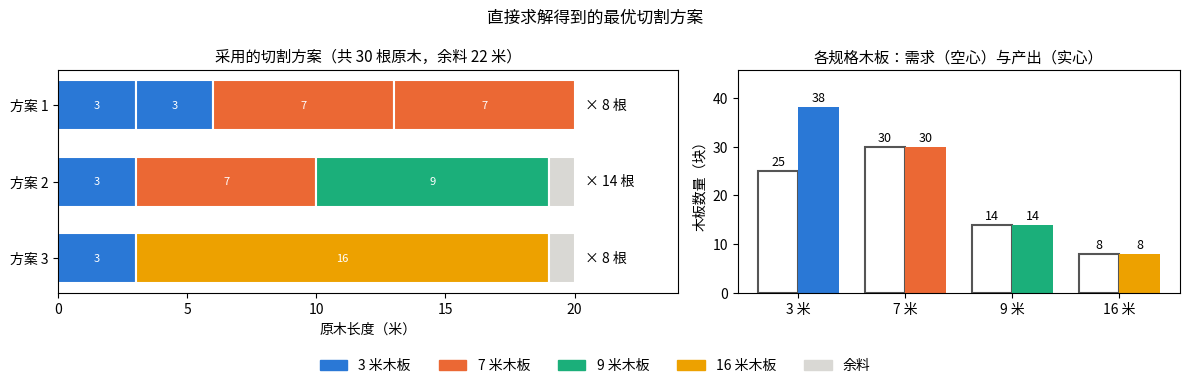

In [10]:
def print_solution(objval, used_plans, types, demand, length):
    """输出求解结果，used_plans 为 [(方案, 切割根数), ...]"""
    total_logs = int(round(objval))
    print(f'最少需要原木 {total_logs} 根\n')
    print('采用的切割方案：')
    total_waste = 0
    produced = [0] * len(types)
    for plan, cnt in used_plans:
        cnt = int(round(cnt))
        desc = ' + '.join(f'{l}米×{a}' for a, l in zip(plan, types) if a > 0)
        waste = length - sum(a * l for a, l in zip(plan, types))
        total_waste += waste * cnt
        for i, a in enumerate(plan):
            produced[i] += a * cnt
        print(f'  [{desc}]  切 {cnt} 根，每根余料 {waste} 米')
    print('\n各规格木板产出情况：')
    for i, l in enumerate(types):
        print(f'  {l:>2}米：需求 {demand[i]:>3} 块，产出 {produced[i]:>3} 块，多切 {produced[i] - demand[i]:>2} 块')
    print(f'\n原木总长度 {total_logs * length} 米，余料合计 {total_waste} 米，'
          f'材料利用率 {1 - total_waste / (total_logs * length):.1%}')


def plot_solution(used_plans, types, demand, length, title=''):
    """左图：采用的切割方案及使用根数；右图：各规格木板的需求与产出"""
    patterns = [p for p, _ in used_plans]
    counts = [int(round(c)) for _, c in used_plans]
    produced = [sum(p[i] * c for p, c in zip(patterns, counts)) for i in range(len(types))]
    total_logs = sum(counts)
    total_waste = sum((length - sum(a * l for a, l in zip(p, types))) * c for p, c in zip(patterns, counts))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={'width_ratios': [1.4, 1]})

    plot_patterns(ax1, patterns, types, length, counts=counts,
                  row_labels=[f'方案 {k + 1}' for k in range(len(patterns))])
    ax1.set_title(f'采用的切割方案（共 {total_logs} 根原木，余料 {total_waste} 米）', fontsize=11)

    xs = range(len(types))
    w = 0.38
    ax2.bar([k - w / 2 for k in xs], demand, w, facecolor='none', edgecolor='#555555', linewidth=1.5)
    ax2.bar([k + w / 2 for k in xs], produced, w, color=[COLORS[i] for i in xs])
    for k in xs:
        ax2.text(k - w / 2, demand[k] + 0.5, str(demand[k]), ha='center', va='bottom', fontsize=9)
        ax2.text(k + w / 2, produced[k] + 0.5, str(produced[k]), ha='center', va='bottom', fontsize=9)
    ax2.set_xticks(list(xs))
    ax2.set_xticklabels([f'{l} 米' for l in types])
    ax2.set_ylabel('木板数量（块）')
    ax2.set_ylim(0, max(max(demand), max(produced)) * 1.2)
    ax2.set_title('各规格木板：需求（空心）与产出（实心）', fontsize=11)

    fig.suptitle(title, fontsize=12)
    pattern_legend(fig, types)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()


if model.status == COPT.OPTIMAL:
    used = [(plans[j], x[j].x) for j in range(num_plans) if x[j].x > 0.5]
    print_solution(model.objval, used, types, demand, length)
    plot_solution(used, types, demand, length, title='直接求解得到的最优切割方案')
else:
    print('未找到最优解，求解状态：', model.status)

最优方案共消耗 30 根原木，比"每根原木只切一种木板"的简单做法（35 根）少用 5 根，降幅 14%。23 种方案中只用到 3 种：方案 1（3 米×2 + 7 米×2）把原木完全用满，方案 2（3 米×1 + 7 米×1 + 9 米×1）和方案 3（3 米×1 + 16 米×1）各剩 1 米余料，600 米原木总计只产生 22 米废料，材料利用率 96.3%。

从左图可以看出最优方案的共同规律：每根原木都以一块长木板为主，再用 3 米的短木板把剩余长度填满。右图显示 7 米、9 米、16 米木板的产出恰好等于需求，3 米木板则多切了 13 块——这是求解器"用短料填余料"带来的副产品，多出来的短板可以入库备用，比留下整段废料更经济。如果业务上不希望多切，可以把需求约束改为等式，或者在目标函数中对多切的木板加入惩罚，模型结构不需要改变。

另外可以注意一下模型的形状：4 行约束、23 列变量，最优解中只有 3 列取正值。规格越多，这种"列多行少、有效列极少"的特点越明显，案例拓展中的列生成算法正是利用了这一结构。

## 案例拓展：利用列生成技术加快模型求解

规格数增加后，可行方案的数量增长很快，先枚举再建模的做法就不再适用。列生成算法从少量方案出发，根据求解结果逐步补充有价值的方案。对应到代码，就是反复执行下面三步：

1. 求解**限制主问题**（RMP，只包含当前已有方案，并把整数变量放松为连续变量），得到每条需求约束的**影子价格** $\pi_i$——它表示第 $i$ 种木板的需求每增加一块，原木总数最少要增加多少；
2. 求解**定价子问题**：在一根原木上寻找总价值 $\sum_i \pi_i a_i$ 最大的切法，其中每块木板的"价值"就是它的影子价格。若最大总价值大于 1（一根原木的成本），说明这种切法物超所值，它的**检验数** $1 - \sum_i \pi_i a_i$ 为负，加入 RMP 可以减少原木用量；
3. 将新方案作为新变量（新列）**加入 RMP**，回到第 1 步。当子问题最大总价值不再超过 1 时，说明已经没有值得加入的方案，迭代结束。

最后将 RMP 的变量改回整数类型再求解一次，得到最终的切割方案。这些概念的详细解释见案例描述，下面重点关注它在 COPT 中的实现。

### 建立限制主问题
RMP 可以看作原模型的缩小版：只保留一部分方案，并将整数变量松弛为连续变量。
$$
\begin{aligned}
    \min \quad & \sum_{j \in J_1} x_j \\
    \text{s.t.} \quad & \sum_{j \in J_1} a_{ji} \cdot x_j \geq d_i, \quad \forall \, i \in I \\
    & x_j \geq 0, \quad \forall \, j \in J_1
\end{aligned}
$$
初始方案取 4 个最简单的方案：每根原木只切一种规格，切割块数取该规格所能容纳的最大值，即 `[6,0,0,0]`、`[0,2,0,0]`、`[0,0,2,0]`、`[0,0,0,1]`。这 4 个方案足以覆盖全部需求，保证 RMP 有可行解。

In [11]:
# 初始方案：每根原木只切一种规格
init_patterns = [[length // types[i] if k == i else 0 for k in range(num_types)] for i in range(num_types)]
print('初始切割方案：', init_patterns)

model_rmp = env.createModel("restricted_master")
model_rmp.setParam("Logging", 0)

# 松弛后的连续变量，目标系数 obj=1 表示每个方案消耗 1 根原木
y = model_rmp.addVars(num_types, lb=0, obj=1.0, vtype=COPT.CONTINUOUS, nameprefix='pattern')

rmp_cons = model_rmp.addConstrs(
    (cp.quicksum(init_patterns[j][i] * y[j] for j in range(num_types)) >= demand[i] for i in range(num_types)),
    nameprefix='demand')

初始切割方案： [[6, 0, 0, 0], [0, 2, 0, 0], [0, 0, 2, 0], [0, 0, 0, 1]]


<font color=#0000FF>
<b>提示：通过 obj 参数设置目标系数</b>
</font>

`Model.addVar()` 与 `Model.addVars()` 都提供 `obj` 参数，用于在创建变量的同时指定它在目标函数中的系数，无需再单独调用 `setObjective()`。列生成需要反复向模型中加入新变量，每加入一个就在 `addVar()` 中给出它的成本，这种方式与算法流程正好对应。

`obj` 只负责系数，优化方向由 `Model.setObjSense()` 决定，默认为最小化，因此 RMP 不必再显式设置。另外，RMP 与子问题在迭代中需要多次求解，为保持输出简洁，这里通过 `setParam("Logging", 0)` 关闭了求解日志。

### 建立定价子问题
定价子问题是一个整数背包问题：原木长度为 20 米，第 $i$ 种规格木板的价值为影子价格 $\pi_i$，求总价值最高的切割方式。决策变量 $a_i$ 是新方案中第 $i$ 种木板的块数。
$$
\begin{aligned}
    \max \quad & \sum_{i \in I} \pi_i \cdot a_i \\
    \text{s.t.} \quad & \sum_{i \in I} l_i \cdot a_i \leq L \\
    & a_i \in \mathbb{N}, \quad \forall \, i \in I
\end{aligned}
$$
子问题的约束（总长度不超过 20 米）在整个迭代过程中保持不变，变化的只有目标系数 $\pi_i$。因此子问题只需建立一次，每轮迭代只更新目标系数。

In [12]:
model_pricing = env.createModel("pricing")
model_pricing.setParam("Logging", 0)

# a_i：新方案中第 i 种规格的切割块数，目标系数在迭代中更新为影子价格
a = model_pricing.addVars(num_types, lb=0, vtype=COPT.INTEGER, nameprefix='a')

model_pricing.addConstr(cp.quicksum(types[i] * a[i] for i in range(num_types)) <= length, name='length')

model_pricing.setObjSense(COPT.MAXIMIZE)

### 列生成迭代
将上述三步写成一个循环：求解 RMP、读取影子价格、更新子问题系数并求解、判断是否加列。每轮迭代打印关键数据，并把 RMP 目标值和影子价格记录到 `history` 中，供后面绘图使用。终止判断中保留 $10^{-6}$ 的浮点容差，避免舍入误差导致多余的迭代。

In [13]:
generated_patterns = list(init_patterns)
history = []      # 每轮迭代的 RMP 目标值与影子价格，供后面绘图
iteration = 0

while True:
    # 求解 RMP，读取需求约束的对偶值（影子价格）
    model_rmp.solve()
    duals = model_rmp.getInfo("Dual", rmp_cons)
    pi = [duals[i] if abs(duals[i]) > 1e-9 else 0.0 for i in range(num_types)]
    history.append({'obj': model_rmp.objval, 'pi': pi})

    # 以影子价格为目标系数求解定价子问题
    for i in range(num_types):
        a[i].setInfo("Obj", pi[i])
    model_pricing.solve()

    new_pattern = [int(round(a[i].x)) for i in range(num_types)]
    reduced_cost = 1 - model_pricing.objval
    print(f'迭代 {iteration}：RMP 目标值 = {model_rmp.objval:.4f}，影子价格 π = {[round(v, 3) for v in pi]}，'
          f'子问题最优值 = {model_pricing.objval:.4f}，检验数 = {reduced_cost:.4f}')

    # 检验数非负则终止，否则将新方案作为新列加入 RMP
    if reduced_cost > -1e-6:
        print('        检验数非负，没有可改进的方案，迭代终止')
        break
    print(f'        加入新方案 {new_pattern}')
    column = cp.Column([rmp_cons[i] for i in range(num_types)], new_pattern)
    model_rmp.addVar(lb=0, obj=1.0, vtype=COPT.CONTINUOUS,
                     name=f'pattern({len(generated_patterns)})', column=column)
    generated_patterns.append(new_pattern)
    iteration += 1

lp_bound = model_rmp.objval
print(f'\n列生成收敛：共生成 {len(generated_patterns) - num_types} 个新方案，RMP 中共有 {len(generated_patterns)} 个方案')
print(f'线性松弛最优值 z_LP = {lp_bound:.4f}，原问题下界 ⌈z_LP⌉ = {math.ceil(lp_bound - 1e-6)}')

迭代 0：RMP 目标值 = 34.1667，影子价格 π = [0.167, 0.5, 0.5, 1.0]，子问题最优值 = 1.3333，检验数 = -0.3333
        加入新方案 [2, 2, 0, 0]
迭代 1：RMP 目标值 = 30.0000，影子价格 π = [0.0, 0.5, 0.5, 1.0]，子问题最优值 = 1.0000，检验数 = 0.0000
        检验数非负，没有可改进的方案，迭代终止

列生成收敛：共生成 1 个新方案，RMP 中共有 5 个方案
线性松弛最优值 z_LP = 30.0000，原问题下界 ⌈z_LP⌉ = 30


<font color=#0000FF>
<b>提示：读取对偶值、修改目标系数与动态加列</b>
</font>

这段循环用到了列生成所依赖的三个接口：

- **读取对偶值**：`Model.getInfo("Dual", constrs)` 一次返回一组约束的对偶值，传入 `tupledict` 时返回同样按下标索引的 `tupledict`；对单条约束也可以直接访问属性 `constr.Pi`。对偶值只在线性规划求解后可用，模型中含有整数变量时无法获取。
- **修改目标系数**：`Var.setInfo("Obj", value)` 直接改写单个变量的目标系数，不需要重新调用 `setObjective()`。修改后再次 `solve()`，COPT 会在上一次求解的基础上热启动，对于每轮只改动少量系数的迭代算法效率很高。
- **动态加列**：`cp.Column(constrs, coeffs)` 描述一个新变量在各约束中的系数，`Model.addVar(..., column=column)` 将其加入模型。对偶值、新列系数与 `obj` 参数三者配合，构成了"求对偶 → 定价 → 加列"的完整闭环。

下面把 `history` 中记录的数据画出来：左图是 RMP 目标值随迭代的变化，右图是每轮迭代中各规格木板的影子价格。

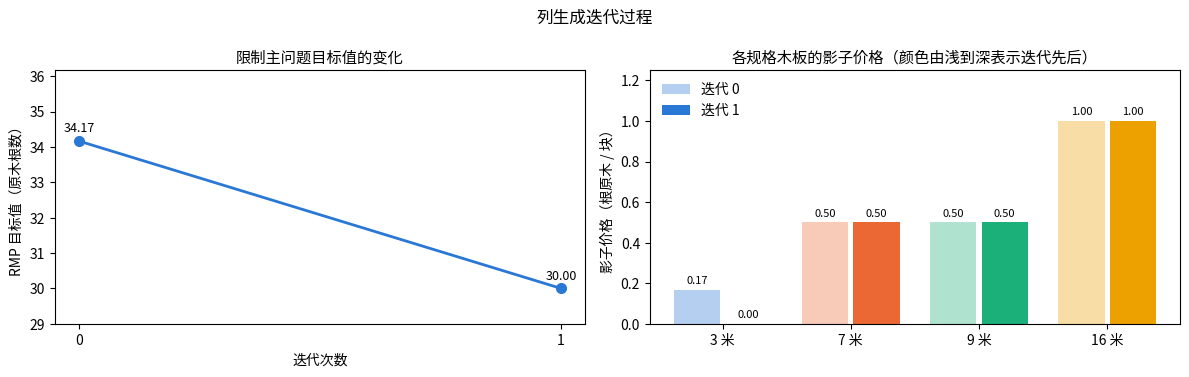

In [14]:
def plot_cg_progress(history, types, title=''):
    """左图：RMP 目标值随迭代的变化；右图：各轮迭代的影子价格"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
    its = list(range(len(history)))
    objs = [h['obj'] for h in history]

    ax1.plot(its, objs, marker='o', color=COLORS[0], linewidth=2, markersize=7)
    for k, v in zip(its, objs):
        ax1.text(k, v + (max(objs) - min(objs) + 1) * 0.05, f'{v:.2f}', ha='center', fontsize=9)
    ax1.set_xticks(its)
    ax1.set_xlabel('迭代次数')
    ax1.set_ylabel('RMP 目标值（原木根数）')
    ax1.set_ylim(min(objs) - 1, max(objs) + 2)
    ax1.set_title('限制主问题目标值的变化', fontsize=11)

    n, m = len(types), len(history)
    w = 0.8 / m
    for k, h in enumerate(history):
        xs = [i + (k - (m - 1) / 2) * w for i in range(n)]
        ax2.bar(xs, h['pi'], w * 0.9, color=[COLORS[i] for i in range(n)],
                alpha=0.35 + 0.65 * k / max(1, m - 1), label=f'迭代 {k}')
        for xx, v in zip(xs, h['pi']):
            ax2.text(xx, v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    ax2.set_xticks(range(n))
    ax2.set_xticklabels([f'{l} 米' for l in types])
    ax2.set_ylabel('影子价格（根原木 / 块）')
    ax2.set_ylim(0, max(max(h['pi']) for h in history) * 1.25)
    ax2.set_title('各规格木板的影子价格（颜色由浅到深表示迭代先后）', fontsize=11)
    ax2.legend(frameon=False)

    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


plot_cg_progress(history, types, title='列生成迭代过程')

第 0 轮只有 4 个单一规格方案，RMP 目标值为 34.17 根（允许"切半根原木"，所以不是整数）。此时的影子价格很直观：一块 3 米木板值 1/6 根原木（一根原木切 6 块），一块 7 米或 9 米木板值半根（一根切 2 块），一块 16 米木板值一整根。用这组价格去找最值钱的切法，得到 3 米×2 + 7 米×2，总价值 $2 \times 0.167 + 2 \times 0.5 = 1.33$，超过一根原木的成本 1，于是被加入 RMP。

第 1 轮加入新方案后，RMP 目标值降到 30，影子价格也随之变化：3 米木板的价格降为 0，因为此时它可以由新方案的余料"免费"提供，不再额外消耗原木。再次求解子问题，最高总价值恰为 1，没有任何方案的检验数为负，迭代结束。此时的 30 就是线性松弛最优值 $z_{LP}$，它告诉我们：无论怎样安排，原木都不可能少于 30 根。

### 恢复整数性并输出结果
列生成收敛时 RMP 的解是线性松弛的最优解，一般不是整数。将 RMP 中的变量改为整数类型再求解一次，即可在已生成的方案上得到整数解。若其目标值等于下界 $\lceil z_{LP} \rceil$，则该解就是原问题的最优解。

最少需要原木 30 根

采用的切割方案：
  [7米×2]  切 2 根，每根余料 6 米
  [9米×2]  切 7 根，每根余料 2 米
  [16米×1]  切 8 根，每根余料 4 米
  [3米×2 + 7米×2]  切 13 根，每根余料 0 米

各规格木板产出情况：
   3米：需求  25 块，产出  26 块，多切  1 块
   7米：需求  30 块，产出  30 块，多切  0 块
   9米：需求  14 块，产出  14 块，多切  0 块
  16米：需求   8 块，产出   8 块，多切  0 块

原木总长度 600 米，余料合计 58 米，材料利用率 90.3%

整数解目标值等于下界 ⌈z_LP⌉ = 30，该解即为原问题的最优解。


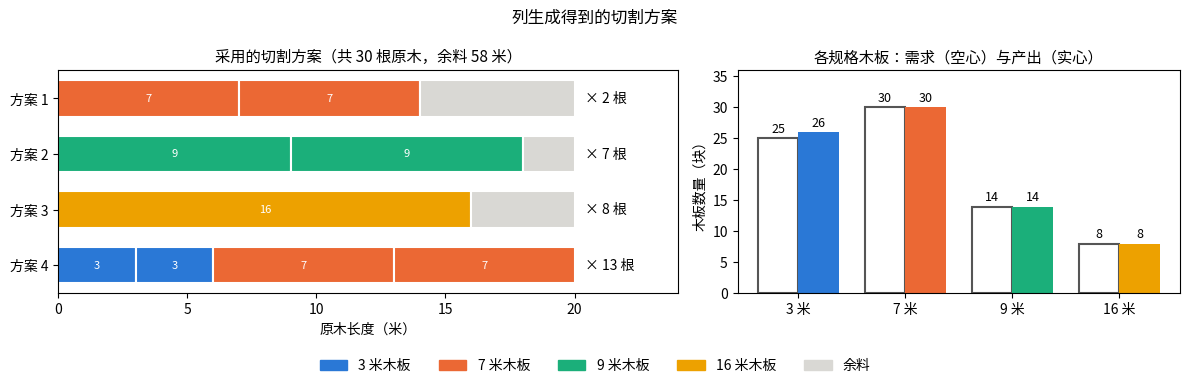

In [15]:
# 在同一模型上把变量改为整数类型
for var in model_rmp.getVars():
    var.setType(COPT.INTEGER)

model_rmp.solve()

if model_rmp.status == COPT.OPTIMAL:
    used_cg = []
    for var in model_rmp.getVars():
        if var.x > 0.5:
            # 从变量所在列的系数还原出切割方案
            col = model_rmp.getCol(var)
            pattern = [0] * num_types
            for k in range(col.getSize()):
                pattern[col.getConstr(k).getIdx()] = int(round(col.getCoeff(k)))
            used_cg.append((pattern, var.x))
    print_solution(model_rmp.objval, used_cg, types, demand, length)

    lower_bound = math.ceil(lp_bound - 1e-6)
    if int(round(model_rmp.objval)) == lower_bound:
        print(f'\n整数解目标值等于下界 ⌈z_LP⌉ = {lower_bound}，该解即为原问题的最优解。')
    else:
        print(f'\n整数解目标值为 {int(round(model_rmp.objval))}，下界为 {lower_bound}，'
              f'当前解与最优解的差距不超过 {int(round(model_rmp.objval)) - lower_bound} 根。')
    plot_solution(used_cg, types, demand, length, title='列生成得到的切割方案')
else:
    print('未找到最优解，求解状态：', model_rmp.status)

<font color=#0000FF>
<b>提示：修改变量类型 Var.setType() 与读取列 Model.getCol()</b>
</font>

- `Var.setType(COPT.INTEGER)` 可以在建模之后修改变量类型，配合 `solve()` 即可在同一个模型对象上完成"先解线性松弛、再解整数模型"的切换，无需重新建模。反过来使用 `setType(COPT.CONTINUOUS)` 则相当于手动做一次线性松弛。
- `Model.getCol(var)` 返回变量所在的列，通过 `getSize()`、`getConstr(k)`、`getCoeff(k)` 可以遍历该列的非零系数。在列生成中，这是从模型中反查每个变量对应哪种切割方案的直接方式，不必在外部另行维护映射关系。

列生成同样得到 30 根原木的方案，与下界 $\lceil z_{LP} \rceil = 30$ 相等，因此可以确认它是最优解。整个过程只涉及 5 种方案（4 个初始方案加 1 个新生成的方案），而直接方法枚举了 23 种。

对比两张结果图可以发现，列生成给出的方案与直接方法的不同：两者都消耗 30 根原木，余料却分别为 58 米和 22 米。这是因为模型的目标函数只统计原木根数，余料和多切的木板都没有体现在目标中，原木数相同的方案对模型而言没有优劣之分；同时列生成只在 5 个已生成的方案上求整数解，可选的组合本身也更少。如果业务上关心余料，可以在目标函数中对余料加入一个较小的惩罚系数，使求解器在原木数相同时优先选择余料更少的方案。

### 更大规模算例对比
本案例的实例规模很小，两种方法的差别并不明显。下面将两种方法分别封装为函数，在一个规格更多的算例上进行对比。

算例：原木 50 米，规格 [4, 6, 7, 9, 11, 13]，需求 [80, 60, 90, 70, 50, 40]

直接枚举：处理 1068 种切割方案，整数最优值 61，耗时 0.299 秒
列生成　：处理 12 种切割方案，线性松弛值 60.200（下界 61），整数解目标值 61，耗时 0.033 秒


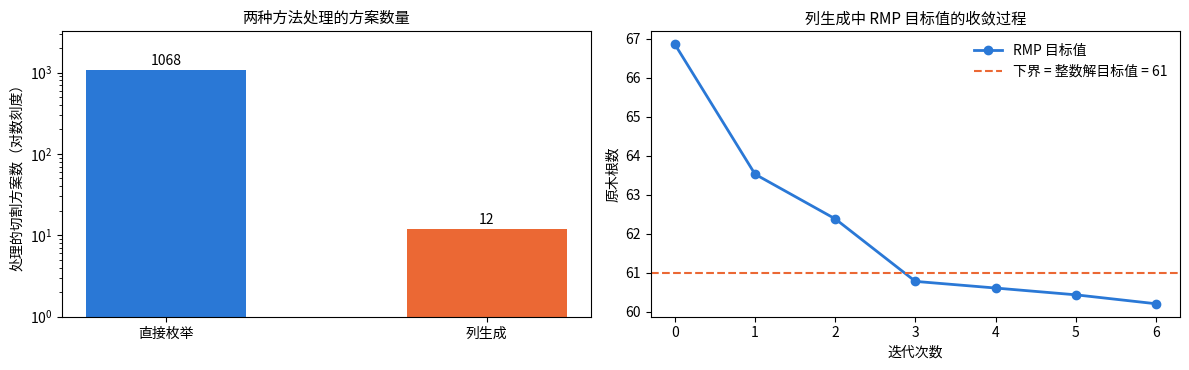

In [16]:
import time

def solve_by_enumeration(length, types, demand):
    """枚举全部方案求解，返回 (方案数, 最优目标值, 求解时间)"""
    plans = enumerate_patterns(length, types)
    n, m = len(types), len(plans)
    model = env.createModel("enumeration")
    model.setParam("Logging", 0)
    x = model.addVars(m, vtype=COPT.INTEGER, nameprefix='x')
    model.setObjective(cp.quicksum(x), COPT.MINIMIZE)
    model.addConstrs((cp.quicksum(plans[j][i] * x[j] for j in range(m)) >= demand[i] for i in range(n)),
                     nameprefix='demand')
    t0 = time.time()
    model.solve()
    return m, model.objval, time.time() - t0


def solve_by_column_generation(length, types, demand):
    """列生成求解，返回 (方案数, 线性松弛最优值, 整数解目标值, 求解时间, 每轮 RMP 目标值)"""
    n = len(types)
    t0 = time.time()
    rmp = env.createModel("rmp")
    rmp.setParam("Logging", 0)
    init = [[length // types[i] if k == i else 0 for k in range(n)] for i in range(n)]
    y = rmp.addVars(n, obj=1.0, nameprefix='pattern')
    cons = rmp.addConstrs((cp.quicksum(init[j][i] * y[j] for j in range(n)) >= demand[i] for i in range(n)),
                          nameprefix='demand')

    pricing = env.createModel("pricing")
    pricing.setParam("Logging", 0)
    a = pricing.addVars(n, vtype=COPT.INTEGER, nameprefix='a')
    pricing.addConstr(cp.quicksum(types[i] * a[i] for i in range(n)) <= length, name='length')
    pricing.setObjSense(COPT.MAXIMIZE)

    num_patterns, rmp_objs = n, []
    while True:
        rmp.solve()
        rmp_objs.append(rmp.objval)
        pi = rmp.getInfo("Dual", cons)
        for i in range(n):
            a[i].setInfo("Obj", pi[i])
        pricing.solve()
        if 1 - pricing.objval > -1e-6:
            break
        column = cp.Column([cons[i] for i in range(n)], [a[i].x for i in range(n)])
        rmp.addVar(obj=1.0, name=f'pattern({num_patterns})', column=column)
        num_patterns += 1

    lp_obj = rmp.objval
    for var in rmp.getVars():
        var.setType(COPT.INTEGER)
    rmp.solve()
    return num_patterns, lp_obj, rmp.objval, time.time() - t0, rmp_objs


# 原木 50 米、6 种规格的算例
length2 = 50
types2  = [4, 6, 7, 9, 11, 13]
demand2 = [80, 60, 90, 70, 50, 40]

m_enum, obj_enum, t_enum = solve_by_enumeration(length2, types2, demand2)
m_cg, lp_cg, obj_cg, t_cg, rmp_objs = solve_by_column_generation(length2, types2, demand2)

print(f'算例：原木 {length2} 米，规格 {types2}，需求 {demand2}\n')
print(f'直接枚举：处理 {m_enum} 种切割方案，整数最优值 {int(round(obj_enum))}，耗时 {t_enum:.3f} 秒')
print(f'列生成　：处理 {m_cg} 种切割方案，线性松弛值 {lp_cg:.3f}（下界 {math.ceil(lp_cg - 1e-6)}），'
      f'整数解目标值 {int(round(obj_cg))}，耗时 {t_cg:.3f} 秒')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))
bars = ax1.bar(['直接枚举', '列生成'], [m_enum, m_cg], width=0.5, color=[COLORS[0], COLORS[1]])
for b, v in zip(bars, [m_enum, m_cg]):
    ax1.text(b.get_x() + b.get_width() / 2, v * 1.15, str(v), ha='center', fontsize=10)
ax1.set_yscale('log')
ax1.set_ylim(1, m_enum * 3)
ax1.set_ylabel('处理的切割方案数（对数刻度）')
ax1.set_title('两种方法处理的方案数量', fontsize=11)

its = list(range(len(rmp_objs)))
ax2.plot(its, rmp_objs, marker='o', color=COLORS[0], linewidth=2, markersize=6, label='RMP 目标值')
lower_bound2 = math.ceil(lp_cg - 1e-6)
if int(round(obj_cg)) == lower_bound2:
    ax2.axhline(lower_bound2, color=COLORS[1], linestyle='--', linewidth=1.5, label=f'下界 = 整数解目标值 = {lower_bound2}')
else:
    ax2.axhline(lower_bound2, color=COLORS[1], linestyle='--', linewidth=1.5, label=f'下界 = {lower_bound2}')
    ax2.axhline(obj_cg, color=COLORS[2], linestyle=':', linewidth=1.5, label=f'整数解目标值 = {int(round(obj_cg))}')
ax2.set_xticks(its)
ax2.set_xlabel('迭代次数')
ax2.set_ylabel('原木根数')
ax2.set_title('列生成中 RMP 目标值的收敛过程', fontsize=11)
ax2.legend(frameon=False)
plt.tight_layout()
plt.show()

在这个算例上，直接枚举需要处理 1068 种方案，列生成从 6 个初始方案出发只新增了 6 列便收敛，两者相差近百倍（左图为对数刻度）。右图显示 RMP 目标值随迭代单调下降，前几轮下降最快，之后逐步趋于平缓，最终停在线性松弛最优值 60.2；整数解 61 根等于下界 $\lceil 60.2 \rceil = 61$，同样是最优解。随着规格数继续增加，可行方案数的增长会更快，枚举法很快就会因方案过多而无法建模，列生成需要处理的列数则增长得平缓许多。

需要说明的是，只在已生成的方案上求整数解是一种启发式做法：如果整数最优解恰好需要某个尚未生成的方案，这一步就会漏掉它。在多数实际问题中这种做法的效果已经足够好，并且可以随时用下界 $\lceil z_{LP} \rceil$ 衡量解的质量。若要严格保证整数最优，则需要在分支定界的每个节点上执行列生成，即分支定价（Branch-and-Price）算法，本案例不再展开。